<h1 style="text-align:center; color:#1ABC9C;">
    Hand Sign Language Recognition (Pose Estimation)
</h1>

<hr>

<p style="text-align:center; font-size:18px;">
    Using MediaPipe, Machine Learning CLassifiers
</p>

<h1 style="text-align:center; color:#1ABC9C;">
    Hand Sign Language Recognition (Pose Estimation)
</h1>

<hr>

<p style="text-align:center; font-size:18px;">
    Using MediaPipe, and ML Classifiers
</p>

## Install Dependencies

In [1]:
%pip install ultralytics mediapipe gradio scikit-learn seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 409.7 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.1 MB 409.7 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.1 MB 409.7 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/8.1 MB 453.2 kB/s eta 0:00:17
   --- -

## Unzipping Dataset

In [ ]:
!unzip archive.zip -d ./Dataset

Archive:  archive.zip
  inflating: ./Dataset/Hand_Sign_Language_A.mp4  
  inflating: ./Dataset/Hand_Sign_Language_B.mp4  
  inflating: ./Dataset/Hand_Sign_Language_F.mp4  
  inflating: ./Dataset/Hand_Sign_Language_S.mp4  


## Import Libraries

In [2]:
import cv2
import os
import numpy as np
import pandas as pd
import mediapipe as mp
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator
import time
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import  LogisticRegression
from sklearn.ensemble import RandomForestClassifier ,StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,ComplementNB,BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier,BaggingClassifier, GradientBoostingClassifier, VotingClassifier , StackingClassifier ,AdaBoostClassifier


c:\Users\alash\OneDrive\Desktop\cv\task3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Check Library Content

In [ ]:
import mediapipe as mp

print(dir(mp))

['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


## Install Mediapipe Model

In [ ]:
!curl -o hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0  7.45M   0   1821   0      0   1771      0 1:13:35   00:01 1:13:34   1780
 12  7.45M  12 936.6k   0      0 461.8k      0   00:16   00:02   00:14 463.0k
 27  7.45M  27  2.05M   0      0 694.1k      0   00:11   00:03   00:08 695.2k
 43  7.45M  43  3.25M   0      0 827.7k      0   00:09   00:04   00:05 828.6k
 59  7.45M  59  4.42M   0      0 901.5k      0   00:08   00:05   00:03 902.4k
 75  7.45M  75  5.64M   0      0 958.8k      0   00:07   00:06   00:01  1.12M
 88  7.45M  88  6.59M   0      0 961.3k      0   00:07   00:07          1.13M
100  7.45M 100  7.45M   0      0 985.9k      0   00:07   00:07          1.13M
100  7.45M 100  7.45M   0      0 985.9k      0   00:07   00:07          1.13M
100  7.45M 100  7.45M   0      0 985.8k      0   00:07   00:07 

# Manipulate Dataset (Data Preprocessing)

In [3]:
# -----------------------------
# Dataset
# -----------------------------
dataset_dir = './Dataset'
videos = os.listdir(dataset_dir)

classes = [v.replace("Hand_Sign_Language_", "").split('.')[0] for v in videos]

# FIX: label map must be based on class, not filename
label_map = {v: i for i, v in enumerate(videos)}

print(classes)
print(label_map)

# -----------------------------
# MediaPipe setup
# -----------------------------
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

model_path = "hand_landmarker.task"

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=1
)

landmarker = HandLandmarker.create_from_options(options)

# -----------------------------
# CONSTANTS
# -----------------------------
MAX_HANDS = 1
LM_SIZE = 21 * 3
FEATURE_SIZE = MAX_HANDS * LM_SIZE

# -----------------------------
# Extract frames → CSV rows
# -----------------------------
def extract_video_frames(video_name, skip_rate=1):

    # ✅ CREATE NEW LANDMARKER HERE (means it know there is new video with new hand signs)
    landmarker = HandLandmarker.create_from_options(options)

    path = os.path.join(dataset_dir, video_name)
    cap = cv2.VideoCapture(path)

    features = []
    label = label_map[video_name]

    print(f"Processing {video_name} - Total frames: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")

    frame_idx = 0
    timestamp = 0
    time_step = 33

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % skip_rate != 0:
            frame_idx += 1
            timestamp += time_step
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        # ✅ NOW SAFE (fresh landmarker)
        result = landmarker.detect_for_video(mp_image, timestamp)
        timestamp += time_step

        hands_data = [[0] * LM_SIZE for _ in range(MAX_HANDS)]

        if result.hand_landmarks:
            for i, hand in enumerate(result.hand_landmarks[:MAX_HANDS]):
                lm_list = []
                for lm in hand:
                    lm_list.extend([lm.x, lm.y, lm.z])
                hands_data[i] = lm_list

        frame_vector = []
        for h in hands_data:
            frame_vector.extend(h)

        features.append(frame_vector)

        frame_idx += 1

    cap.release()

    return features, label

['A', 'B', 'F', 'S']
{'Hand_Sign_Language_A.mp4': 0, 'Hand_Sign_Language_B.mp4': 1, 'Hand_Sign_Language_F.mp4': 2, 'Hand_Sign_Language_S.mp4': 3}


## Creating CSV File

In [4]:
# -----------------------------
# BUILD CSV DATASET
# -----------------------------
X = []
y = []

for video in videos:
    frames, label = extract_video_frames(video)

    for f in frames:
        X.append(f)
        y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# -----------------------------
# SAVE CSV
# -----------------------------
df = pd.DataFrame(X)
df.columns = [f"f{i}" for i in range(FEATURE_SIZE)]
df["label"] = y

df.to_csv("hand_sign_frame_dataset.csv", index=False)

print("Saved: hand_sign_frame_dataset.csv")

Processing Hand_Sign_Language_A.mp4 - Total frames: 416
Processing Hand_Sign_Language_B.mp4 - Total frames: 355
Processing Hand_Sign_Language_F.mp4 - Total frames: 365
Processing Hand_Sign_Language_S.mp4 - Total frames: 291
X shape: (1427, 63)
y shape: (1427,)
Saved: hand_sign_frame_dataset.csv


##  Hand Sign Language Dataset Description

### Overview
This dataset is generated from video recordings of hand sign gestures using **MediaPipe Hand Landmarker**.  
Each row represents a **single video frame**, transformed into a numerical feature vector suitable for machine learning models.

---

###  Feature Representation

- Each frame contains **21 hand landmarks**
- Each landmark has **3 coordinates**:
  - `x` → normalized horizontal position
  - `y` → normalized vertical position
  - `z` → relative depth

 Total features per frame:


---

###  Dataset Structure

| Component | Description |
|----------|------------|
| `f0 → f62` | Flattened landmark coordinates (x, y, z for each point) |
| `label` | Target class (hand sign category) |

- Total columns: **64**
- Feature columns: **63**
- Label column: **1**

---

###  Labels

Each label corresponds to a specific hand sign:

| Label | Class |
|------|------|
| 0 | A |
| 1 | B |
| 2 | F |
| 3 | S |

---

###  Data Processing Pipeline

1. Videos are loaded from the dataset directory  
2. Frames are extracted using OpenCV  
3. Every *N-th frame* is sampled to reduce redundancy  
4. MediaPipe detects hand landmarks per frame  
5. Landmarks are flattened into a feature vector  
6. Frames are labeled based on the source video  
7. All data is stored in a CSV file  

---

###  Key Characteristics

- **Data Type:** Numerical (float32)
- **Normalization:** Coordinates are normalized in range `[0, 1]`
- **Missing Hands:** Represented as zero vectors
- **Temporal Info:** Not included (frame-based dataset)

---

###  Use Cases

This dataset is suitable for: 21 landmarks × 3 coordinates = 63 features

- Hand gesture classification
- Traditional ML models (SVM, Random Forest, XGBoost)
- Deep learning models (MLP, CNN, Transformer with sequences)
- Real-time sign language recognition systems

---

###  Notes

- The dataset is **frame-independent**, meaning temporal relationships between frames are not preserved.
- For sequence-based models (e.g., LSTM), a different dataset format (video sequences) is required.

## Dataset Description

In [ ]:
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f54,f55,f56,f57,f58,f59,f60,f61,f62,label
0,0.339260,0.837340,-3.479059e-07,0.411824,0.684744,-0.025846,0.428968,0.472861,-0.033854,0.412406,...,0.193046,0.551113,-0.099133,0.239037,0.621341,-0.087457,0.228618,0.623137,-0.074164,0
1,0.354490,0.851602,-6.370928e-07,0.412678,0.689754,-0.028559,0.424673,0.466858,-0.030034,0.408484,...,0.194751,0.567288,-0.052308,0.248666,0.633682,-0.036545,0.231664,0.644520,-0.020541,0
2,0.352711,0.852877,-6.705509e-07,0.409520,0.683818,-0.024814,0.425208,0.457158,-0.026611,0.411784,...,0.194303,0.564915,-0.057766,0.250149,0.627966,-0.039616,0.234887,0.631865,-0.022651,0
3,0.350268,0.853879,-7.118360e-07,0.409719,0.681461,-0.023154,0.424993,0.455289,-0.022416,0.410941,...,0.194289,0.563828,-0.056458,0.249847,0.627686,-0.038801,0.231906,0.633105,-0.022413,0
4,0.350672,0.854154,-6.953414e-07,0.409528,0.681345,-0.024265,0.424313,0.457165,-0.024749,0.411293,...,0.194218,0.564064,-0.057605,0.250344,0.626841,-0.039160,0.233166,0.634322,-0.022218,0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
f0,1373.0,4.331571e-01,1.347605e-01,0.000000,3.527739e-01,0.412174,5.107956e-01,8.938572e-01
f1,1373.0,8.273245e-01,1.255881e-01,0.000000,7.252587e-01,0.844490,9.268284e-01,1.060281e+00
f2,1373.0,-7.806126e-08,4.666986e-07,-0.000001,-5.289850e-07,0.000000,3.474580e-07,9.482133e-07
f3,1373.0,4.556111e-01,1.487906e-01,0.000000,3.756247e-01,0.461146,5.354886e-01,8.726505e-01
f4,1373.0,7.021318e-01,1.469731e-01,0.000000,5.980737e-01,0.716844,8.304341e-01,9.914740e-01
...,...,...,...,...,...,...,...,...
f59,1373.0,-4.318319e-02,4.638104e-02,-0.240590,-6.837118e-02,-0.043377,-1.338295e-02,9.637926e-02
f60,1373.0,4.718519e-01,1.694243e-01,0.000000,3.517970e-01,0.450314,6.000226e-01,8.740337e-01
f61,1373.0,4.020703e-01,1.961636e-01,0.000000,2.303613e-01,0.365753,6.180480e-01,8.344331e-01
f62,1373.0,-3.554897e-02,4.737087e-02,-0.246993,-6.122674e-02,-0.037033,-6.647530e-03,1.131247e-01


In [ ]:
df['label'].value_counts()


label
0    416
2    365
1    355
3    291
Name: count, dtype: int64

### Remove Duplicates

In [5]:
df.duplicated().sum()

np.int64(54)

In [5]:
df = df.drop_duplicates(keep='first')

### Missing Data

In [7]:
df.isnull().sum()

f0       0
f1       0
f2       0
f3       0
f4       0
        ..
f59      0
f60      0
f61      0
f62      0
label    0
Length: 64, dtype: int64

### Outliers

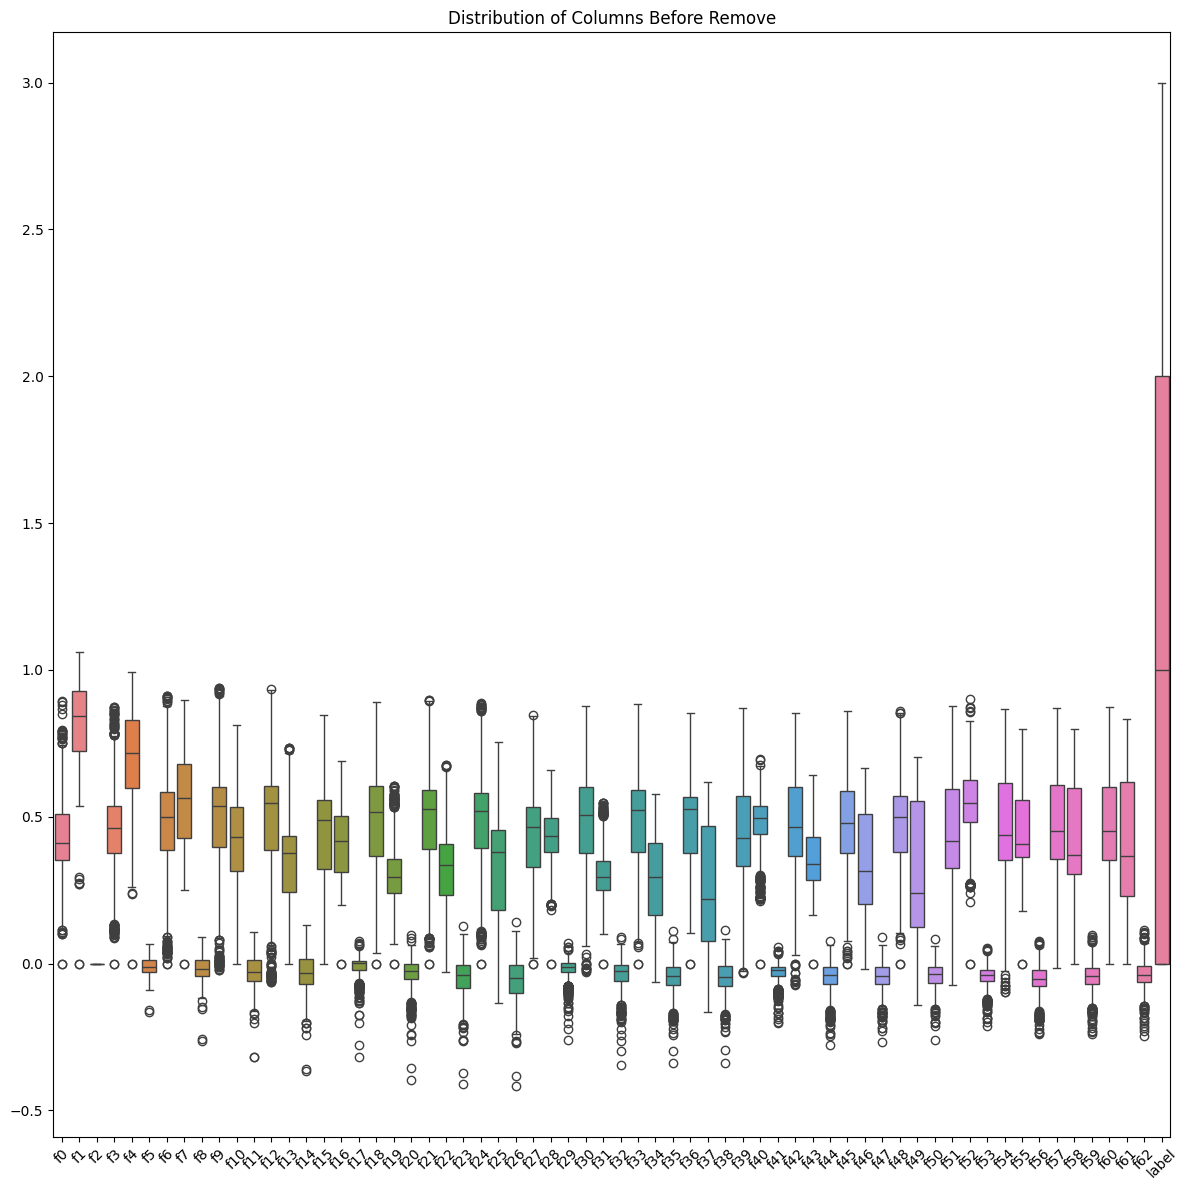

In [8]:
plt.figure(figsize=(12,12))
sns.boxplot(data=df[df.columns])
plt.title("Distribution of Columns Before Remove")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bi Varate Analysis (Relationship Between two Variables)

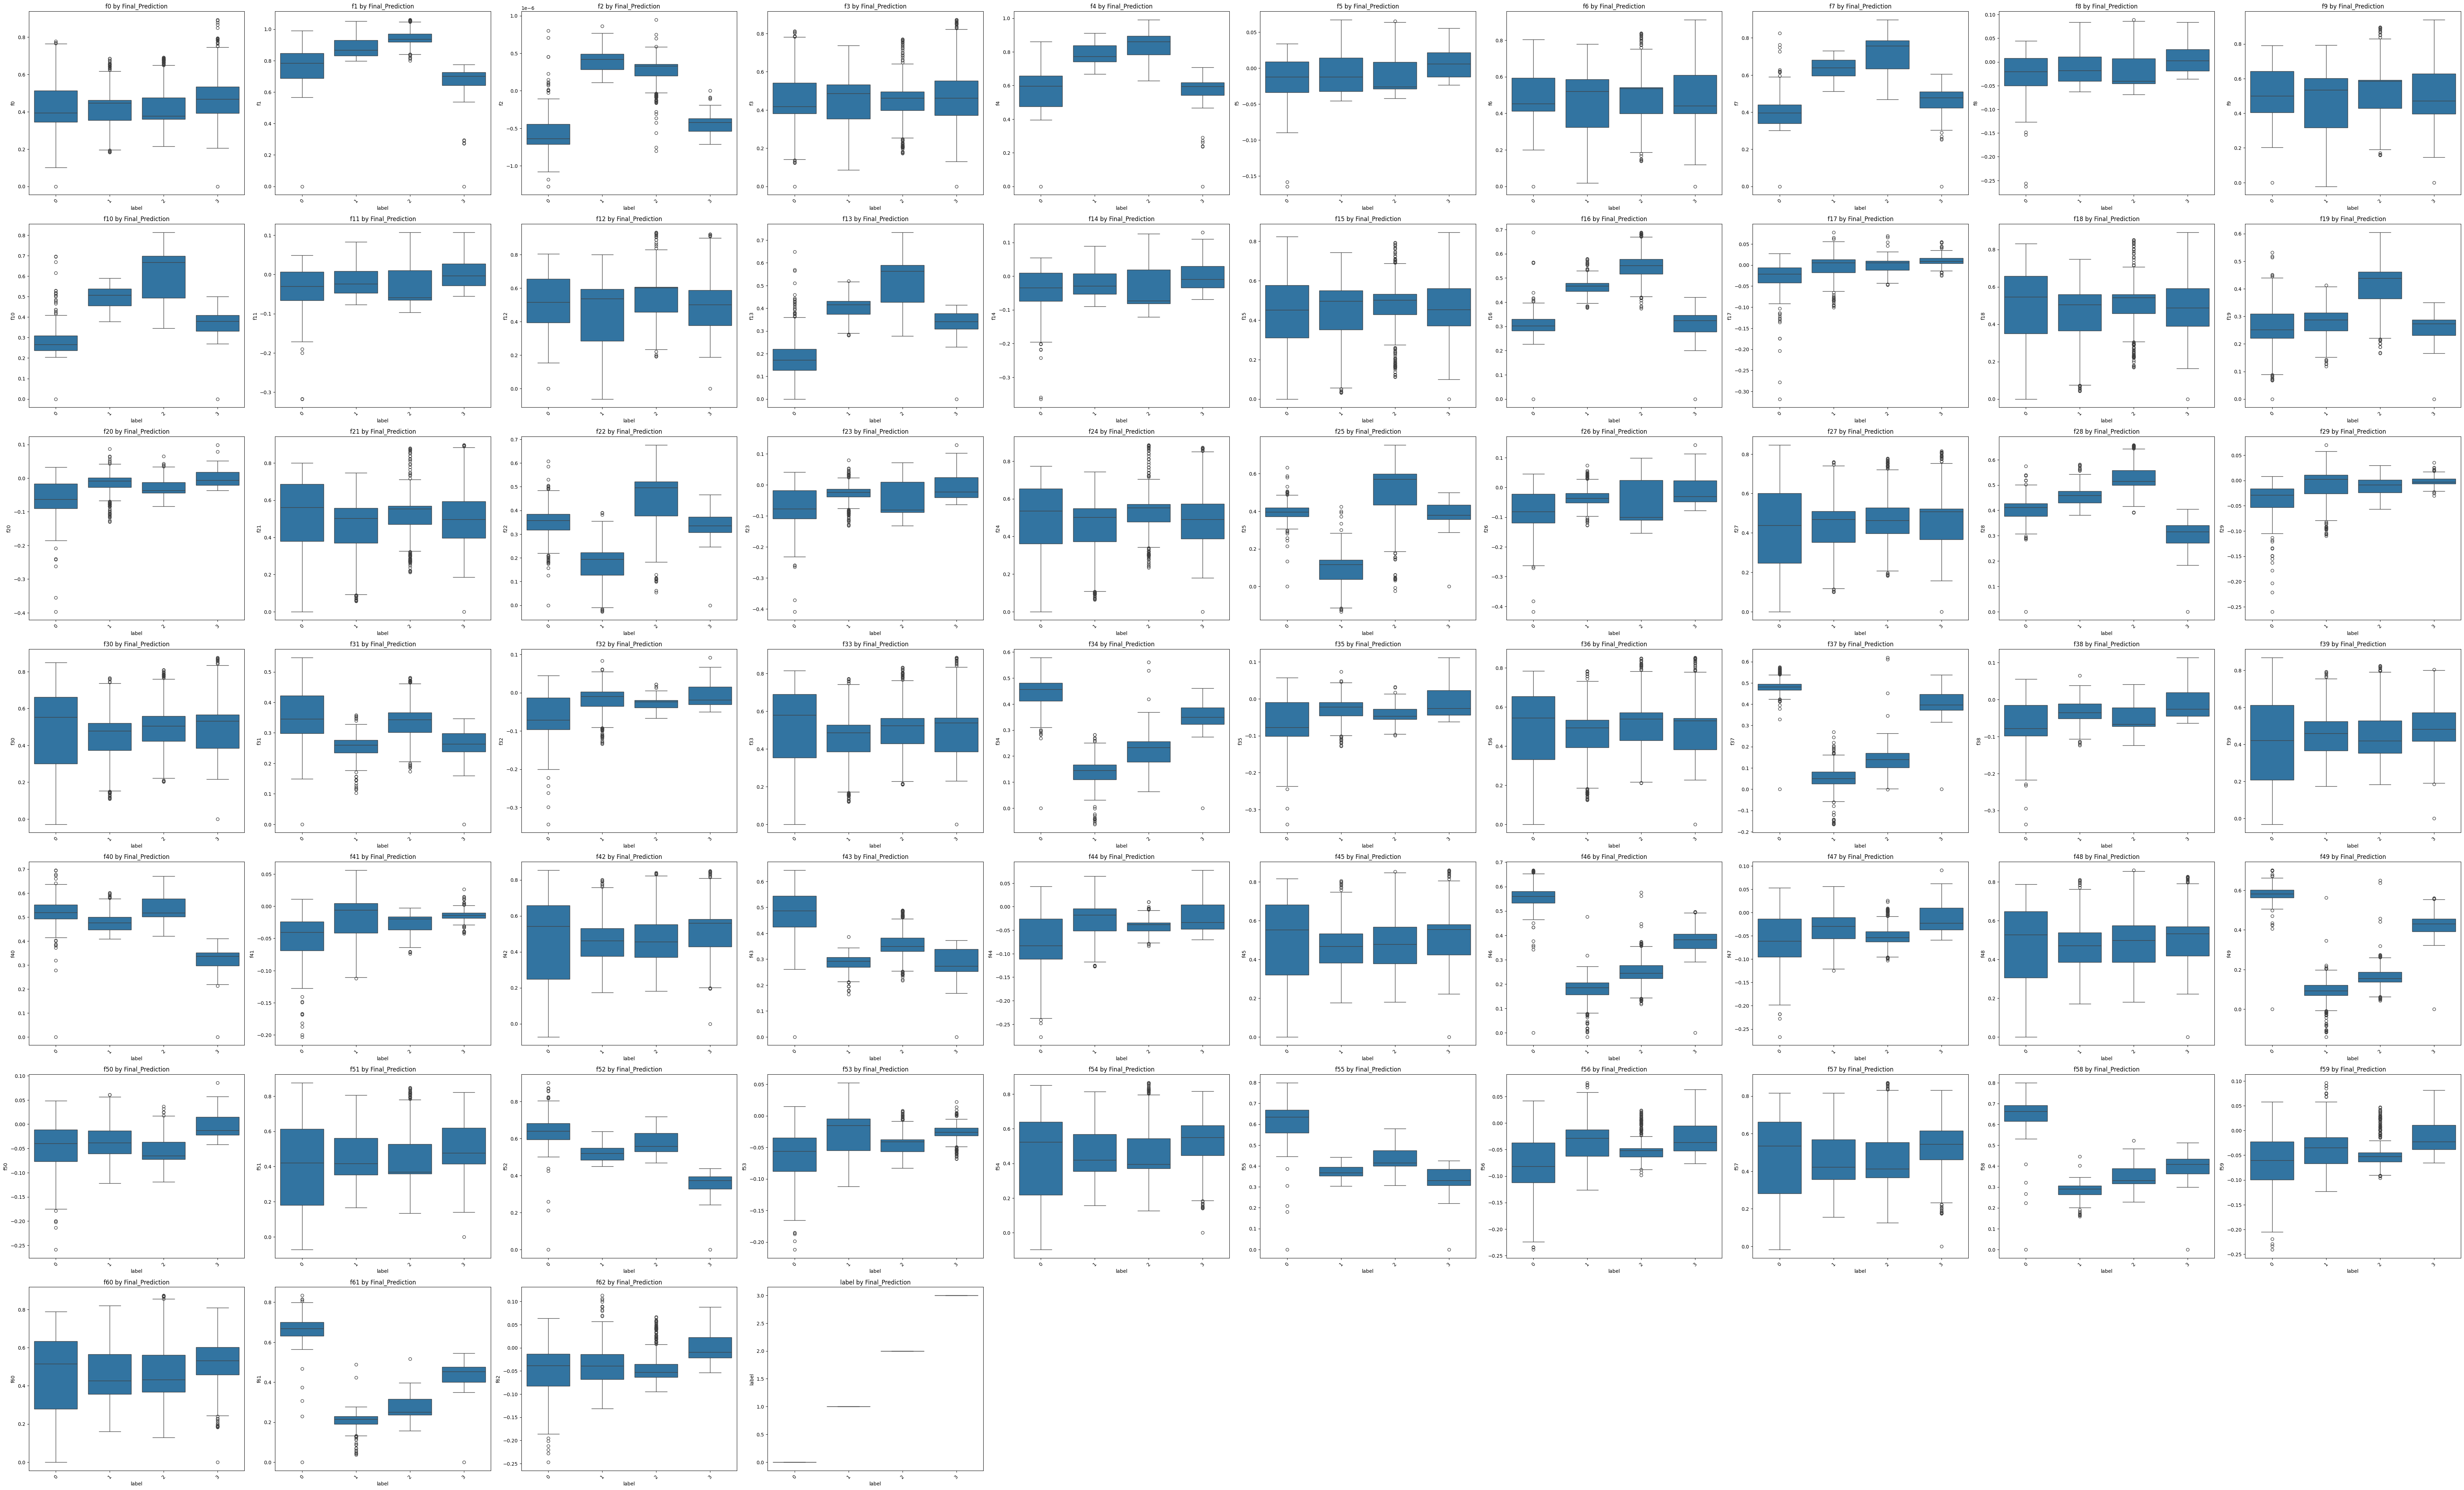

In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(70, 60))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(10,10, i)  
    sns.boxplot(x='label', y=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} by Final_Prediction')
plt.tight_layout()
plt.show()

## Data Cleaning

`Data Is Cleaned..`

## Splitting

In [6]:
data_input = df.drop(columns='label')
data_output = df['label']
data_input.shape

(1373, 63)

In [7]:

from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(
    data_input, data_output, test_size=0.25, random_state=0
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=0
)

### Feature Scaling / Normalization

In [8]:
from sklearn.preprocessing import StandardScaler ,RobustScaler,MinMaxScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  # fit ONLY on train
X_test = scaler.transform(X_test)        # transform test
X_val = scaler.transform(X_val)          # transform validation

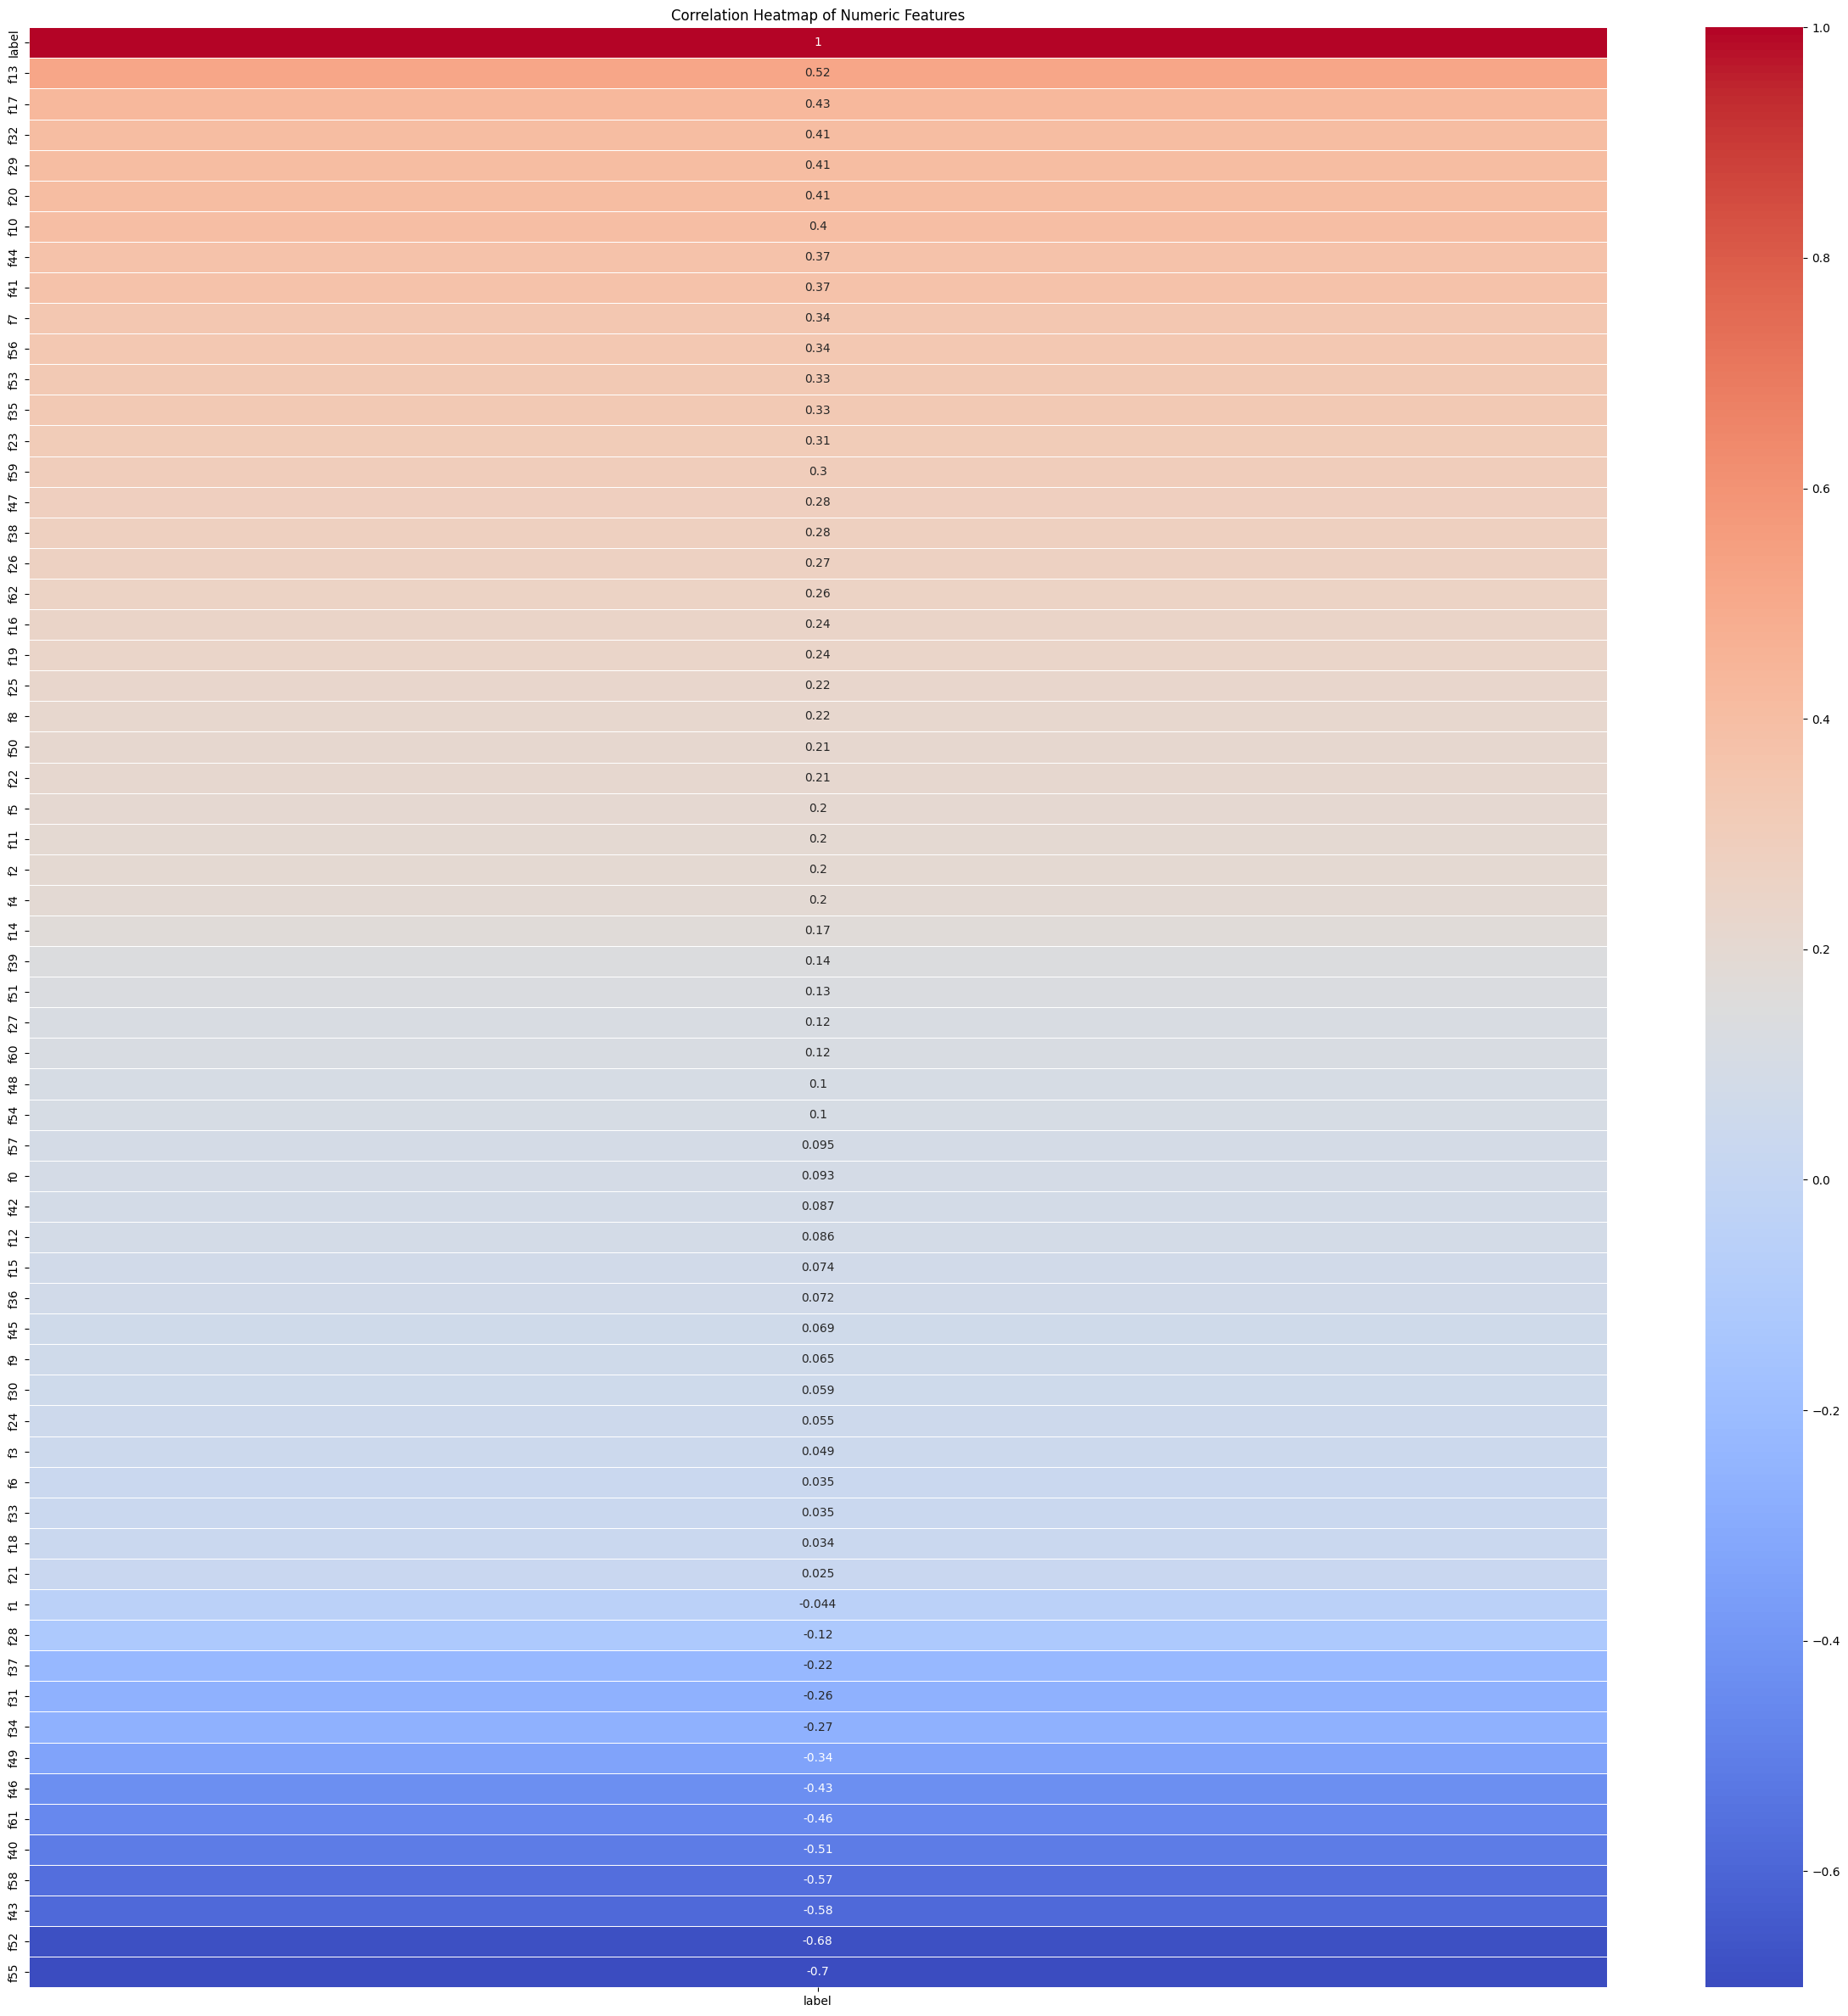

In [22]:

plt.figure(figsize=(30, 30))

corr = df[df.columns].corr()
corr_with_rating = corr['label'].sort_values(ascending=False).to_frame()

sns.heatmap(corr_with_rating, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Model Training && Evaluation

In [9]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
  
)
from sklearn.pipeline import Pipeline


In [10]:

models = [  ('lr', LogisticRegression( solver='lbfgs')),
            ('gnb', GaussianNB()),
            ('mnb',MultinomialNB()),
            ('cnb',ComplementNB()),
            ('bnb',BernoulliNB()),
            ('knn', KNeighborsClassifier(n_neighbors=2)),
            ('rf', RandomForestClassifier(n_estimators=50,random_state=42)),
            ('dt', DecisionTreeClassifier(max_depth=2,random_state=42)),
]

ensemble_models = [
("Bagging", BaggingClassifier(
        estimator=models[0][1],  # using Logistic Regression as base estimator
        n_estimators=50,
        random_state=42
    )),

    ("GradientBoosting", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )),

    ("Voting", VotingClassifier(
        estimators=[
            ("lr", models[0][1]),
            ("rf", models[6][1])
        ],
        voting='soft'   # better than hard
    )),

    ("Stacking", StackingClassifier(
        estimators=[
             ("lr", models[0][1]),
             ("rf", models[6][1])
        ],
        final_estimator=LogisticRegression(),
        passthrough=False
    )),
    ("AdaBoost", AdaBoostClassifier(
        estimator=models[0][1],  # using Logistic Regression as base estimator
        n_estimators=50,
        random_state=42
        ))


            ]

In [11]:
def eval_model(grid, X_train, y_train, X_val, y_val):
    
    y_pred_train = grid.predict(X_train)
    y_pred_val = grid.predict(X_val)
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_val = accuracy_score(y_val, y_pred_val)
    return acc_train, acc_val

---------------------------------------
Accuracy: (0.9961089494163424, 0.9922480620155039)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.97      0.99      0.98       102
           2       0.99      0.97      0.98        86
           3       0.98      1.00      0.99        60

    accuracy                           0.99       344
   macro avg       0.99      0.99      0.99       344
weighted avg       0.99      0.99      0.99       344



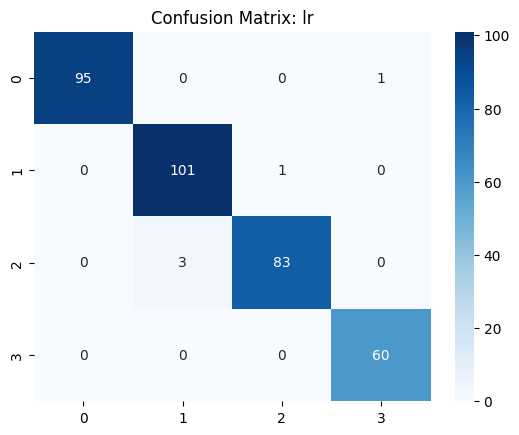

---------------------------------------
Accuracy: (0.9520103761348897, 0.9418604651162791)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.86      1.00      0.92       102
           2       1.00      0.79      0.88        86
           3       0.97      1.00      0.98        60

    accuracy                           0.94       344
   macro avg       0.96      0.95      0.95       344
weighted avg       0.95      0.94      0.94       344



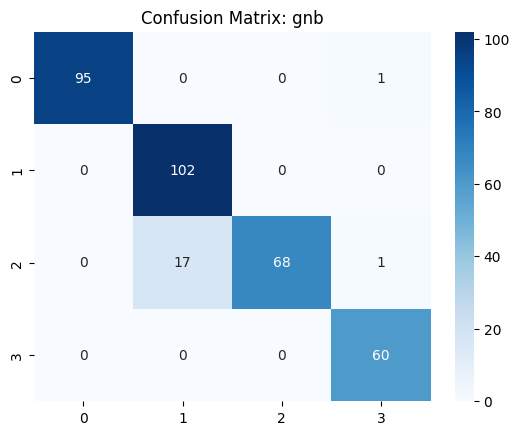

Error processing in model mnb: Negative values in data passed to MultinomialNB (input X).
skipping...
Error processing in model cnb: Negative values in data passed to ComplementNB (input X).
skipping...
---------------------------------------
Accuracy: (0.9247730220492867, 0.9186046511627907)
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        96
           1       0.83      0.96      0.89       102
           2       0.99      0.77      0.86        86
           3       0.90      1.00      0.94        60

    accuracy                           0.92       344
   macro avg       0.93      0.92      0.92       344
weighted avg       0.93      0.92      0.92       344



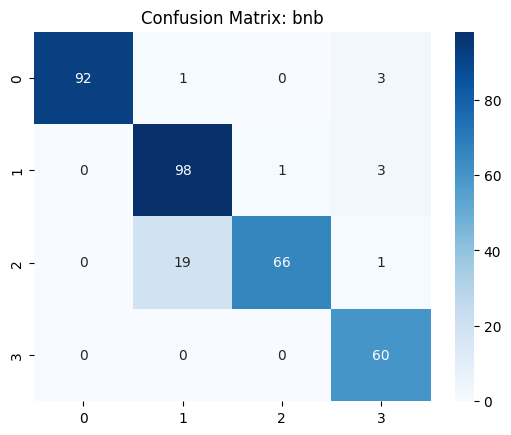

---------------------------------------
Accuracy: (0.9974059662775616, 0.9922480620155039)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.99      1.00      1.00       102
           2       1.00      0.99      0.99        86
           3       0.98      1.00      0.99        60

    accuracy                           0.99       344
   macro avg       0.99      0.99      0.99       344
weighted avg       0.99      0.99      0.99       344



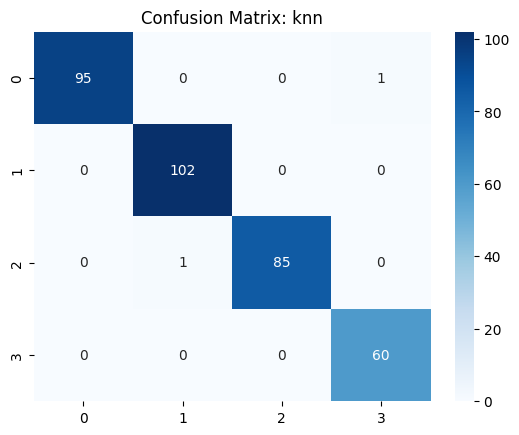

---------------------------------------
Accuracy: (1.0, 0.9883720930232558)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.97      1.00      0.99       102
           2       1.00      0.97      0.98        86
           3       0.98      1.00      0.99        60

    accuracy                           0.99       344
   macro avg       0.99      0.99      0.99       344
weighted avg       0.99      0.99      0.99       344



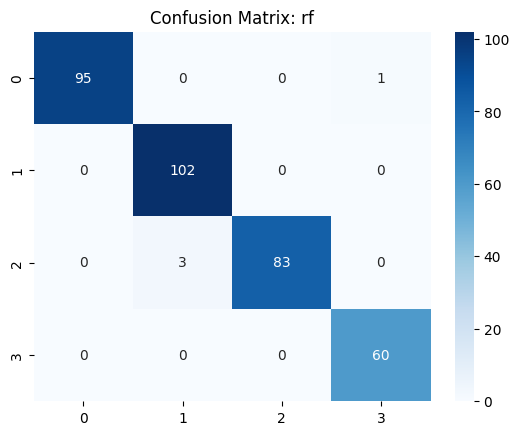

---------------------------------------
Accuracy: (0.7522697795071336, 0.7441860465116279)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.00      0.00      0.00       102
           2       0.46      1.00      0.63        86
           3       0.98      1.00      0.99        60

    accuracy                           0.70       344
   macro avg       0.61      0.75      0.65       344
weighted avg       0.56      0.70      0.61       344



c:\Users\alash\OneDrive\Desktop\cv\task3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alash\OneDrive\Desktop\cv\task3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alash\OneDrive\Desktop\cv\task3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

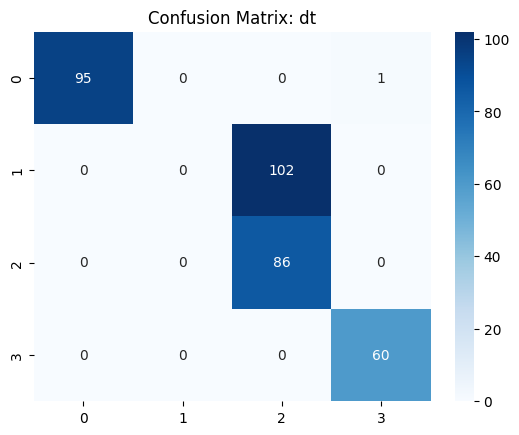

---------------------------------------
Accuracy: (0.9961089494163424, 0.9922480620155039)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.97      0.98      0.98       102
           2       0.98      0.97      0.97        86
           3       0.98      1.00      0.99        60

    accuracy                           0.98       344
   macro avg       0.98      0.98      0.98       344
weighted avg       0.98      0.98      0.98       344



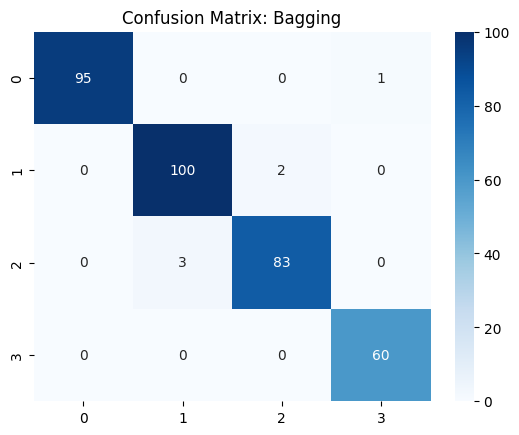

---------------------------------------
Accuracy: (1.0, 0.9922480620155039)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.98      1.00      0.99       102
           2       1.00      0.98      0.99        86
           3       0.98      1.00      0.99        60

    accuracy                           0.99       344
   macro avg       0.99      0.99      0.99       344
weighted avg       0.99      0.99      0.99       344



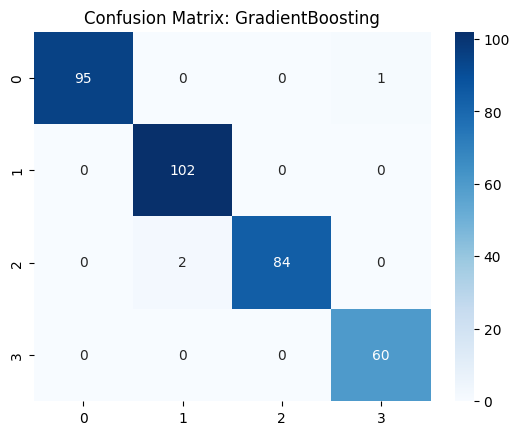

---------------------------------------
Accuracy: (0.9987029831387808, 0.9961240310077519)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.98      1.00      0.99       102
           2       1.00      0.98      0.99        86
           3       0.98      1.00      0.99        60

    accuracy                           0.99       344
   macro avg       0.99      0.99      0.99       344
weighted avg       0.99      0.99      0.99       344



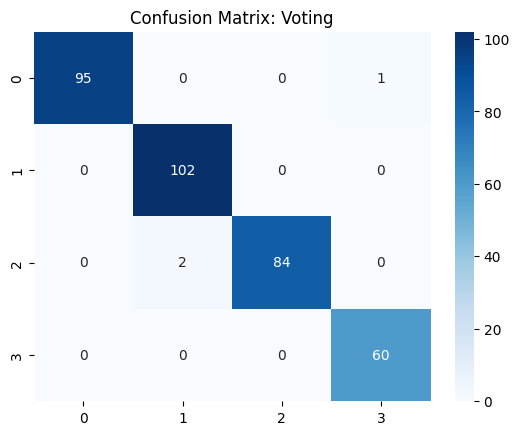

---------------------------------------
Accuracy: (1.0, 0.9961240310077519)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.99      1.00      1.00       102
           2       1.00      0.99      0.99        86
           3       0.98      1.00      0.99        60

    accuracy                           0.99       344
   macro avg       0.99      0.99      0.99       344
weighted avg       0.99      0.99      0.99       344



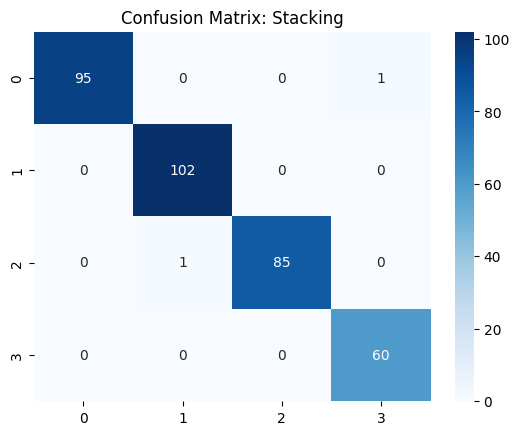

---------------------------------------
Accuracy: (0.9636835278858625, 0.9573643410852714)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.91      0.97      0.94       102
           2       0.96      0.88      0.92        86
           3       0.98      1.00      0.99        60

    accuracy                           0.96       344
   macro avg       0.96      0.96      0.96       344
weighted avg       0.96      0.96      0.96       344



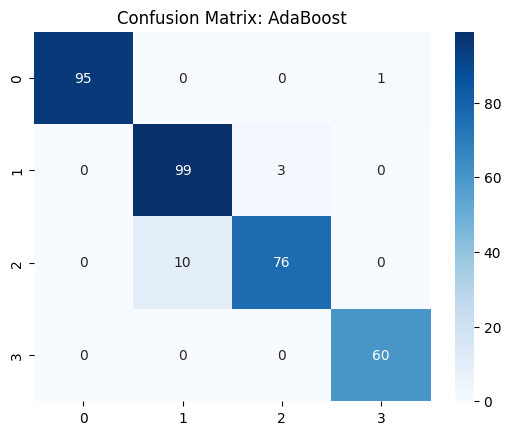

All models processed.


In [12]:
model_accuracies=[]
trained_models=[]

for modell in models + ensemble_models:
    name, clf = modell


    model = Pipeline([
    ("scaler", scaler),
    (f"{name}", clf)
])
    try:
        model.fit(X_train, y_train)

        y_pred= model.predict(X_test)



        accuracy_tra,accuracy_val = eval_model(model, X_train, y_train, X_val, y_val)
        trained_models.append((name,model))
        model_accuracies.append((name, (accuracy_tra,accuracy_val)))
   

        print("---------------------------------------")
        print("Accuracy:", (accuracy_tra,accuracy_val))
        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix: {name}')
        plt.show()
    except Exception as e:
        print(f"Error processing in model {name}: {e}")
        print("skipping...")
print("All models processed.")


In [50]:
os.makedirs('.\\Pose_Estimation\\models', exist_ok=True)
os.makedirs('.\\Pose_Estimation\\workspace', exist_ok=True)

In [51]:
import pickle

for name, model in trained_models:

  with open(f'.\\Pose_Estimation\\models\\{name}.pkl', 'wb') as f:
         pickle.dump(model, f)
         #print(model)

In [52]:
import joblib
joblib.dump(scaler, '.\\Pose_Estimation\\workspace\\Scaler.pkl')

['.\\Pose_Estimation\\workspace\\Scaler.pkl']

               Model  Accuracy(t)  Accuracy(v)
9           Stacking     1.000000     0.996124
7   GradientBoosting     1.000000     0.992248
4                 rf     1.000000     0.988372
8             Voting     0.998703     0.996124
3                knn     0.997406     0.992248
0                 lr     0.996109     0.992248
6            Bagging     0.996109     0.992248
10          AdaBoost     0.963684     0.957364
1                gnb     0.952010     0.941860
2                bnb     0.924773     0.918605
5                 dt     0.752270     0.744186


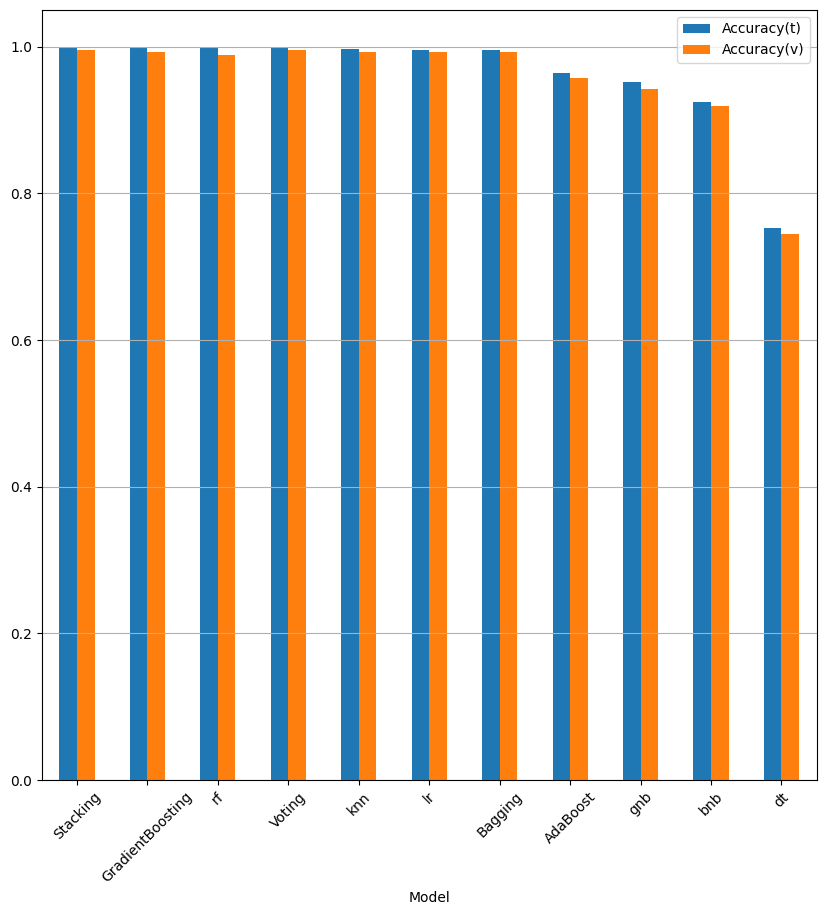

In [63]:
results=[]

i=0
for name,acc in model_accuracies:
    results.append((name,acc[0],acc[1],))
    i+=1

results = pd.DataFrame(results)
results.columns=['Model','Accuracy(t)','Accuracy(v)']
results.sort_values(by='Accuracy(t)',ascending=False,inplace=True)
print (results)
results.plot.bar(x='Model', y=['Accuracy(t)',"Accuracy(v)"], figsize=(10, 10))
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [ ]:
print(f'Best Model Is : ({results['Model'].iloc[0]})')
with open('.\\Pose_Estimation\\workspace\\Best_model.txt', 'w') as f:
    f.write(results['Model'].iloc[0])

Stacking


## Real-Time Detection

In [ ]:
def real_time():

    import cv2
    import mediapipe as mp
    import numpy as np

    # -----------------------------
    # MEDIAPIPE SETUP
    # -----------------------------
    BaseOptions = mp.tasks.BaseOptions
    HandLandmarker = mp.tasks.vision.HandLandmarker
    HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
    VisionRunningMode = mp.tasks.vision.RunningMode

    options = HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path="hand_landmarker.task"),
        running_mode=VisionRunningMode.VIDEO,
        num_hands=1
    )

    landmarker = HandLandmarker.create_from_options(options)

    # -----------------------------
    # CAMERA
    # -----------------------------
    cap = cv2.VideoCapture(0)

    timestamp = 0
    TIME_STEP = 33000

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        h, w, _ = frame.shape

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        result = landmarker.detect_for_video(mp_image, int(timestamp))
        timestamp += TIME_STEP

        label = "No Hand Detected"

        # -----------------------------
        # FEATURE EXTRACTION + PREDICTION
        # -----------------------------
        if result.hand_landmarks:

            hand = result.hand_landmarks[0]

            lm_list = []
            for lm in hand:
                lm_list.extend([lm.x, lm.y, lm.z])

            features = np.array(lm_list).reshape(1, -1)

            # scale + predict
            features = scaler.transform(features)
            pred = model.predict(features)[0]
#pred = trained_models[1][0].predict(features)[0]
            # convert label safely
            class_name = str(pred)
            if "label_map" in globals():
                class_name = label_map.get(pred, str(pred))

            label = f"Hand Detected | Class: {class_name}"

            # -----------------------------
            # DRAW LANDMARKS
            # -----------------------------
            for lm in hand:
                x = int(lm.x * w)
                y = int(lm.y * h)
                cv2.circle(frame, (x, y), 3, (0, 255, 0), -1)

        # -----------------------------
        # DISPLAY TEXT
        # -----------------------------
        cv2.putText(
            frame,
            label,
            (30, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255),
            2
        )

        cv2.imshow("Real-Time Hand Sign Recognition", frame)

        if cv2.waitKey(1) & 0xFF == 27:
            break

    cap.release()
    cv2.destroyAllWindows()

In [20]:
real_time()